In [94]:
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import ADASYN
from collections import Counter
from sklearn.preprocessing import MinMaxScaler



In [95]:
data=pd.read_csv('../../data/processed/data_selected.csv')
data.head()

,Date,GARCH_Vol,KOSDAQ,KOSPI 200 Low,Shanghai Comp,GJR_GARCH_Vol,GJR_VaR_95,Gold Spot,TOPIX,JPY/KRW,KOSPI 200 Close,NASDAQ,KODEX 200,Signal2_Sell,KOSPI 200_RSI14,Actual_Return(%),Risk_Label
0,2009-04-17,1.432045,483.799988,169.710007,2503.935059,1.426891,-2.246073,867.400024,875.0,13.371,171.330002,1673.069946,17370.0,0,63.873746,-0.233192,0
1,2009-04-20,1.378327,491.940002,169.039993,2557.456055,1.379095,-2.169582,887.000000,876.0,13.536,172.300003,1608.209961,17480.0,0,76.439644,0.564563,0
2,2009-04-21,1.332280,497.190002,167.660004,2535.827881,1.312454,-2.062932,882.099976,855.0,13.727,171.960007,1643.849976,17480.0,0,74.958299,-0.197523,0
3,2009-04-22,1.283201,509.899994,171.860001,2461.345947,1.273734,-2.000966,891.799988,856.0,13.726,174.399994,1646.119995,17715.0,0,74.084326,1.408955,0
4,2009-04-23,1.287644,514.090027,173.899994,2463.954102,1.210839,-1.900311,905.900024,862.0,13.618,176.139999,1652.209961,17895.0,0,69.951956,0.992765,0


### 데이터 분할

In [96]:

# train:valid:test 5:3:2
data_train = data[:int(len(data) * 0.5)]
data_valid = data[int(len(data) * 0.5):int(len(data) * 0.8)]
data_test = data[int(len(data) * 0.8):]

# X, y 분리
X_train = data_train.drop(['Risk_Label', 'Date'], axis=1)  # 설명변수, Date는 ML에서 불필요
y_train = data_train['Risk_Label']  # 반응변수
X_valid = data_valid.drop(['Risk_Label', 'Date'], axis=1)
y_valid = data_valid['Risk_Label']
X_test = data_test.drop(['Risk_Label', 'Date'], axis=1)
y_test = data_test['Risk_Label']

label_name_map = {0: 'LowRisk', 1: 'HighRisk'}
y_train_named = y_train.map(label_name_map)

print('train/valid/test:', len(data_train), len(data_valid), len(data_test))
print('y_train class:', y_train_named.value_counts().to_dict())


train/valid/test: 2054 1233 822
y_train class: {'LowRisk': 1764, 'HighRisk': 290}


### Min-Max Scaling

In [97]:
def scalering(data):
    scaler = MinMaxScaler().set_output(transform="pandas")
    data_scaled = scaler.fit_transform(data)
    return data_scaled

# 스케일링
X_train_scaled = scalering(X_train)
X_valid_scaled = scalering(X_valid)
X_test_scaled = scalering(X_test)
 
print('train/valid/test:', len(data_train), len(data_valid), len(data_test))
print('y_train class:', y_train.value_counts().to_dict())


train/valid/test: 2054 1233 822
y_train class: {0: 1764, 1: 290}


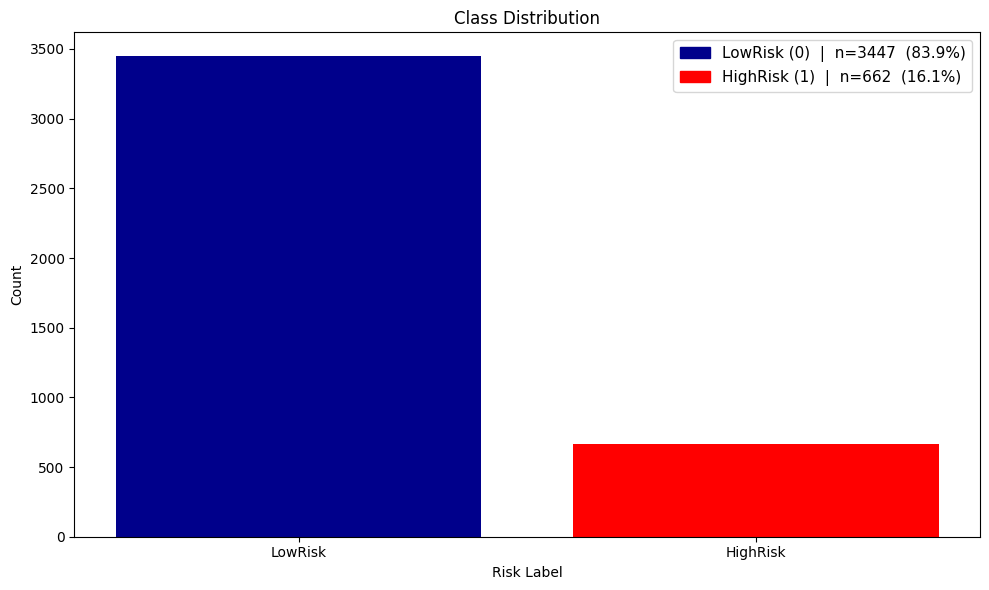

In [98]:
# 클래스 불균형 확인
counts = data['Risk_Label'].value_counts().sort_index()
label_name_map = {0: 'LowRisk', 1: 'HighRisk'}
colors = {0: 'darkblue', 1: 'red'}
total = counts.sum()

x_labels = [label_name_map.get(idx, str(idx)) for idx in counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    x_labels,
    counts.values,
    color=[colors.get(k, 'grey') for k in counts.index]
)

legend_labels = [
    f"{label_name_map.get(idx, idx)} ({idx})  |  n={cnt}  ({cnt/total*100:.1f}%)"
    for idx, cnt in zip(counts.index, counts.values)
]
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(idx, 'grey'))
    for idx in counts.index
]
ax.legend(legend_patches, legend_labels, fontsize=11)

ax.set_xlabel('Risk Label')
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()


### **ADA**ptive **SYN**

In [99]:
# 1. X, y 분리 (Date는 인덱스로 설정, 피처에서 제외)
X = data_train.drop(columns=['Date', 'Risk_Label'])

# 라벨을 0/1로 통일 (0=LowRisk, 1=HighRisk)
y_raw = data_train['Risk_Label']
if y_raw.dtype == object:
    y = y_raw.astype(str).str.strip().str.lower().map({'lowrisk': 0, 'highrisk': 1}).astype(int)
else:
    y = y_raw.astype(int)

# 2. ADASYN 적용
adasyn = ADASYN(
    sampling_strategy='auto',
    random_state=1,
    n_neighbors=5
)

X_resampled, y_resampled = adasyn.fit_resample(X, y)


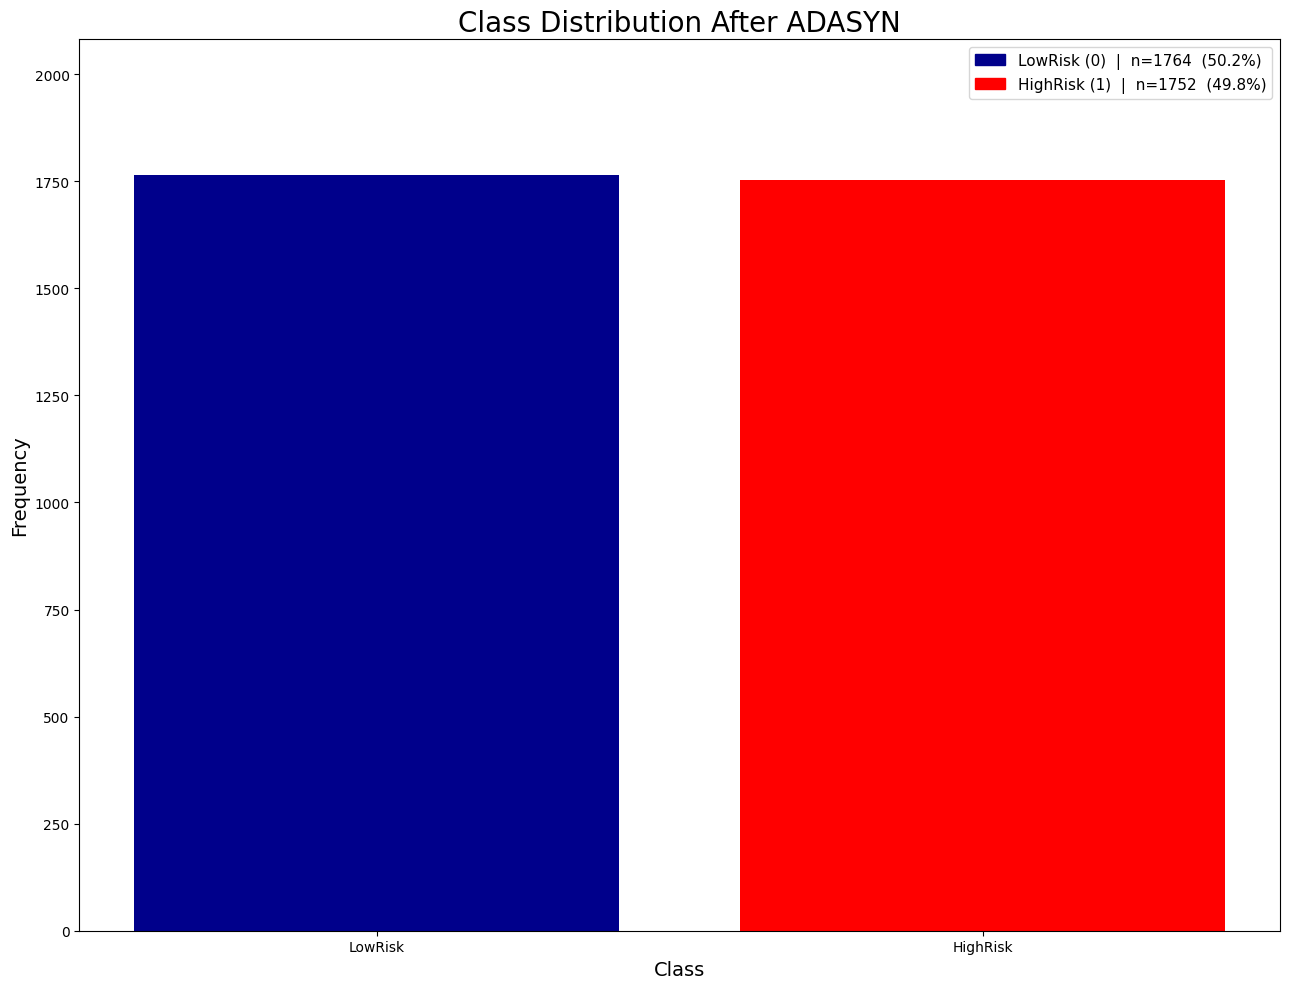

In [100]:
# 3. ADASYN 적용 후 클래스 분포 확인
counts = pd.Series(y_resampled).value_counts().sort_index()
label_name_map = {0: 'LowRisk', 1: 'HighRisk'}
colors = {0: 'darkblue', 1: 'red'}
total = counts.sum()

x_labels = [label_name_map.get(int(idx), str(idx)) for idx in counts.index]

fig, ax = plt.subplots(figsize=(13, 10))
ax.bar(
    x_labels,
    counts.values,
    color=[colors.get(int(k), 'grey') for k in counts.index]
)

# legend에 이름, index, count, 비율 표시
legend_labels = [
    f"{label_name_map.get(int(idx), idx)} ({int(idx)})  |  n={cnt}  ({cnt/total*100:.1f}%)"
    for idx, cnt in zip(counts.index, counts.values)
]
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(int(idx), 'grey'))
    for idx in counts.index
]
ax.legend(legend_patches, legend_labels, fontsize=11)

ax.set_xlabel('Class', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.set_title('Class Distribution After ADASYN', fontsize=20)
plt.ylim(0, max(counts.values) * 1.18)
plt.tight_layout()
plt.show()


In [101]:

# 4. 다시 데이터프레임으로 합치기
data_train_adasyn = X_resampled.copy()
data_train_adasyn['Risk_Label'] = y_resampled
data_train_adasyn.head()


,GARCH_Vol,KOSDAQ,KOSPI 200 Low,Shanghai Comp,GJR_GARCH_Vol,GJR_VaR_95,Gold Spot,TOPIX,JPY/KRW,KOSPI 200 Close,NASDAQ,KODEX 200,Signal2_Sell,KOSPI 200_RSI14,Actual_Return(%),Risk_Label
0,1.432045,483.799988,169.710007,2503.935059,1.426891,-2.246073,867.400024,875.0,13.371,171.330002,1673.069946,17370.0,0,63.873746,-0.233192,0
1,1.378327,491.940002,169.039993,2557.456055,1.379095,-2.169582,887.000000,876.0,13.536,172.300003,1608.209961,17480.0,0,76.439644,0.564563,0
2,1.332280,497.190002,167.660004,2535.827881,1.312454,-2.062932,882.099976,855.0,13.727,171.960007,1643.849976,17480.0,0,74.958299,-0.197523,0
3,1.283201,509.899994,171.860001,2461.345947,1.273734,-2.000966,891.799988,856.0,13.726,174.399994,1646.119995,17715.0,0,74.084326,1.408955,0
4,1.287644,514.090027,173.899994,2463.954102,1.210839,-1.900311,905.900024,862.0,13.618,176.139999,1652.209961,17895.0,0,69.951956,0.992765,0


In [102]:
# 5. CSV로 저장
data_train_adasyn.to_csv('../../data/processed/ADASYN/data_train_adasyn.csv', index=False)
data_valid.to_csv('../../data/processed/ADASYN/data_valid.csv', index=False)
data_test.to_csv('../../data/processed/ADASYN/data_test.csv', index=False) 